In this notebook we recreate the plots that were presented in 'Cosmological perturbations with ultralight vector dark matter fields: numerical implementation in CLASS'.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
import math

### LCDM

In [2]:
# Planck 2018  Cosmological parameters
#h_planck = 0.6766              # TT,TE,EE+lowE+lensing+BAO
#omega_m = 0.3111*h_planck**2   # TT,TE,EE+lowE+lensing+BAO
#omega_cdm = 0.11933            # TT,TE,EE+lowE+lensing+BAO
#Omega_Lambda = 0.6889          # TT,TE,EE+lowE+lensing+BAO
#omega_b = 0.02242              # TT,TE,EE+lowE+lensing+BAO
#tau_reio = 0.0561              # TT,TE,EE+lowE+lensing+BAO
#As = 2.105 * 1.e-9             # TT,TE,EE+lowE+lensing+BAO
#ns = 0.9665                    # TT,TE,EE+lowE+lensing+BAO
#N_eff = 2.99                   # TT,TE,EE+lowE+lensing+BAO
#theta_s = 1.04119              # TT,TE,EE+lowE+lensing+BAO

h_planck = 0.6688              # TT,TE,EE+lowE
omega_m = 0.321*h_planck**2   # TT,TE,EE+lowE
omega_cdm = 0.1206            # TT,TE,EE+lowE
Omega_Lambda = 0.679          # TT,TE,EE+lowE
omega_b = 0.02212              # TT,TE,EE+lowE
tau_reio = 0.05522              # TT,TE,EE+lowE
As = 2.092 * 1.e-9             # TT,TE,EE+lowE
ns = 0.962                    # TT,TE,EE+lowE
theta_s = 1.04077              # TT,TE,EE+lowE


In [ ]:
colors = ['slateblue','tomato','darkseagreen','orchid','darkslategrey']#['b','red','g','darkorange','darkslategrey']#['orange','g','y','b','r']#['r', 'b', 'y', 'm', 'g']
masses =  [1.e-26, 1.e-25, 1.e-24, 1.e-23] # eV
masses_Mpc = [mass*1.56373846613383*1.e29 for mass in masses]# Mpc^-1

# Precision overrides (previously hard-coded in include/precisions.h, now set per-notebook)
precision_settings = {
    'tol_thermo_integration': 1.0e-5,
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-7,
    'k_per_decade_primordial': 30.0,
}

lcdm = Class()
lcdm_settings = {'omega_b':omega_b,'Omega_cdm' : omega_cdm/h_planck**2,'100*theta_s': theta_s,'A_s' : As
                 ,'n_s':ns,'tau_reio':tau_reio,
                 'YHe': 'BBN','output':'tCl mPk dTk vTk','gauge':'synchronous',
                 'P_k_max_h/Mpc':100.0, 'format': 'camb', 'ic' : 'ad','P_k_ini type' : 'analytic_Pk',
                 'z_pk': '0,10,100', 'Omega_k' : 0., 'N_ncdm' : 0}
lcdm_settings.update(precision_settings)
lcdm.set(lcdm_settings)

lcdm.compute()
all_k_lcdm = lcdm.get_perturbations()
background_lcdm = lcdm.get_background()

common_settings  = {
            #'h' : h_planck,
            '100*theta_s': theta_s,
            #'T_cmb' : 2.7255,
            'omega_b' : omega_b,
            #'N_ur' : N_eff,
            'Omega_cdm' : 0.000001,
            'Omega_dcdmdr' : 0.0,
            'N_ncdm' : 0,
            'Omega_k' : 0.,
            'Omega_fld' : 0.,
            'Omega_vf' : omega_cdm/h_planck**2,
            'attractor_ic_vf' : 'yes',
            #'vf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass,
            'vf_tuning_index' : 3,
            'YHe' : 'BBN',
            'tau_reio':tau_reio,
            'output' : 'tCl,pCl,lCl,mPk',
            'P_k_max_h/Mpc' : 100.,
            #'k_output_values':str(k_out).strip('[]'),
            'ic' : 'ad',
            'gauge' : 'synchronous',
            'P_k_ini type' : 'analytic_Pk',
            'A_s' : As,
            'n_s' : ns,
            'l_max_scalars' : 2500,
            'P_k_max_h/Mpc' : 100.,
            'z_pk': '0,10,100',
            'format': 'camb',
            'vector_background_mode' : 'bianchi',
            #'theta_Ak': np.pi/2
            }
common_settings.update(precision_settings) 

As a benchmark, let's define the LCDM cosmology.

# $\theta$ sweep

In [4]:
angles = [0, np.pi/8, np.pi/4, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/2']

### $m = 10^{-18} eV$

In [5]:
mass = 1.e-18
z0=0
cosmo_angles = {}
angles = [0, np.pi/8, np.pi/4, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/2']
mass_Mpc = mass*1.56373846613383*1.e29
color_angles = ['b','red','olive','orange']

lcdm19 = Class()
lcdm19.set(lcdm_settings)
lcdm19.set({'P_k_max_h/Mpc': 800.0})
lcdm19.compute()

for m in range(len(angles)):

    cosmo_angles[m] = Class()
    cosmo_angles[m].set(common_settings)
    cosmo_angles[m].set({'P_k_max_h/Mpc' : 800.})
    cosmo_angles[m].set({'vf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass})
    cosmo_angles[m].set({'vector_background_mode' : 'bianchi'})
    cosmo_angles[m].set({'theta_Ak' : angles[m]})
    cosmo_angles[m].compute()

FileNotFoundError: pk_sfdm_zoom/p_k_SCALAR_zoom_m=10^{-18}eV_z=0 not found.

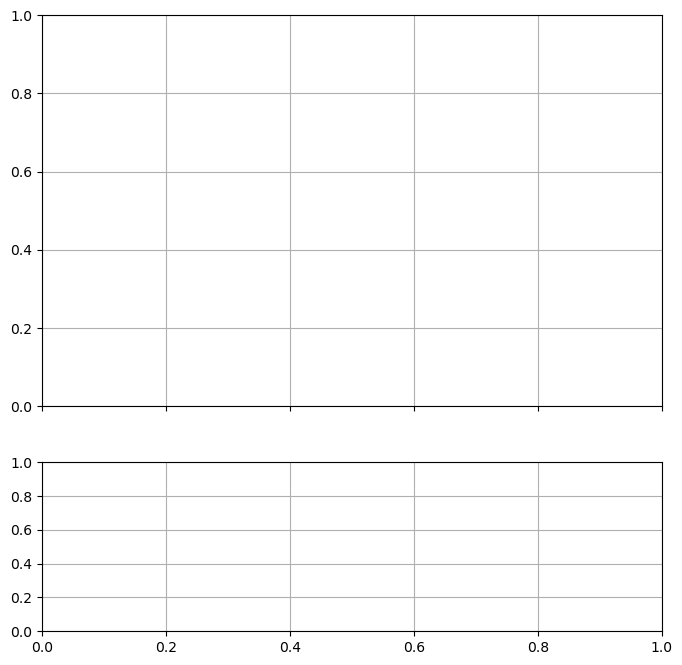

In [7]:
# m = 10^{-18} eV
k_bigm_max = 800.
color_angles = ['tab:blue','tab:red','tab:olive','tab:orange']
def Pk_z0(z0):

    fig, axes = plt.subplots(2,1,sharex=True, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1.3]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(angles)):

        kk = np.logspace(1, np.log10(k_bigm_max),5000) # k in h/Mpc
        Pk = [] # P(k) in (Mpc/h)**3
        Pk_scalar = np.loadtxt('pk_sfdm_zoom/p_k_SCALAR_zoom_m=10^{%s}eV_z=%s'% (str(mass)[-3:],str(z0))) # P(k) in (Mpc/h)**3
        h = cosmo_angles[m].h() # get reduced Hubble for conversions to 1/Mpc 
        background = cosmo_angles[m].get_background()
        background_z = background['z']
        background_a = 1/(1+background_z)
        # K_J

        background_H_over_m = background['H [1/Mpc]']/mass_Mpc # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kj =  a_osc * np.sqrt(mass_Mpc * H_osc) 

        for k in kk:
            Pk.append(cosmo_angles[m].pk(k*h,z0)*h**3) # function .pk(k,z)

        if m == 0:
            data = []
            data = Pk
        
        Pk_lcdm = [] # P(k) in (Mpc/h)**3
        h_lcdm = lcdm19.h() # get reduced Hubble for conversions to 1/Mpc
        for k in kk:
            Pk_lcdm.append(lcdm19.pk(k*h,z0)*h_lcdm**3) # function .pk(k,z)
        
        #Plot the Matter Power Spectrum
        axes[0].loglog(kk, Pk, color_angles[m], label=r'$\gamma_k=%s$'% str(angles_label[m]), lw=3)
        if angles[m] == angles[-1]:
            axes[0].loglog(kk, Pk_scalar, 'g--', label=r'SFDM', lw=3)
            axes[0].loglog(kk, Pk_lcdm, 'k--', label=r'CDM', lw=3)
            axes[0].legend(loc='lower left',fontsize=14)
        if m > 0:  
            axes[1].loglog(kk, 100*np.abs(1-(np.array(Pk)/np.array(data))), color_angles[m], lw=3)
    axes[0].set_ylim([0.1*min(Pk), 2*max(Pk_lcdm)])
    #axes[0].set_xlim([1.e-2, 1.e0])
    axes[0].vlines(kj/h, min(Pk), max(Pk_lcdm), colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].vlines(kj/h, 1.e-3, 1.e2, colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].set_ylim([1.e-3, 1.e2])
    axes[1].set_xlim([1.e1, k_bigm_max])
    axes[1].set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=14)
    axes[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=14)
    axes[1].set_ylabel(r'Percentage diff. (%)', size=14)
    axes[0].set_title('(z=%s)'%z0)
    axes[0].text(100, 0.2*max(Pk_lcdm), r'$m = 10^{%s} \rm{eV}$' % str(mass)[-3:], bbox=dict(facecolor='white', boxstyle='round',alpha=0.8),fontsize=15)
    #axes[0].text(1.05*kj/h, min(Pk), r'$k_J$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=18)
    fig.tight_layout()
    plt.savefig('../../Figures/Pk_angle_comparison_zoom_m=^{%s}eV_z=%s.pdf'%(str(mass)[-3:],str(z0)))
    plt.show()
    
Pk_z0(0)
Pk_z0(20)

### $m = 10^{-19} eV$

In [9]:
mass = 1.e-19
z0=0
cosmo_angles = {}
angles = [0, np.pi/8, np.pi/4, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/2']
mass_Mpc = mass*1.56373846613383*1.e29
color_angles = ['b','red','olive','orange']
k_bigm_max = 800.

for m in range(len(angles)):

    cosmo_angles[m] = Class()
    cosmo_angles[m].set(common_settings)
    cosmo_angles[m].set({'theta_Ak' : angles[m]})
    cosmo_angles[m].set({'vf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass})
    cosmo_angles[m].set({'P_k_max_h/Mpc' : k_bigm_max})
    cosmo_angles[m].compute()

In [ ]:
# m = 10^{-19} eV
color_angles = ['tab:blue','tab:red','tab:olive','tab:orange']
def Pk_z0(z0):

    fig, axes = plt.subplots(2,1,sharex=True, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1.3]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(angles)):

        kk = np.logspace(1, np.log10(k_bigm_max),5000) # k in h/Mpc
        Pk = [] # P(k) in (Mpc/h)**3
        Pk_scalar = np.loadtxt('pk_sfdm_zoom/p_k_SCALAR_zoom_m=10^{%s}eV_z=%s'% (str(mass)[-3:],str(z0))) # P(k) in (Mpc/h)**3
        h = cosmo_angles[m].h() # get reduced Hubble for conversions to 1/Mpc 
        background = cosmo_angles[m].get_background()
        background_z = background['z']
        background_a = 1/(1+background_z)
        # K_J

        background_H_over_m = background['H [1/Mpc]']/mass_Mpc # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kj =  a_osc * np.sqrt(mass_Mpc * H_osc) 

        for k in kk:
            Pk.append(cosmo_angles[m].pk(k*h,z0)*h**3) # function .pk(k,z)

        if m == 0:
            data = []
            data = Pk
        
        Pk_lcdm = [] # P(k) in (Mpc/h)**3
        h_lcdm = lcdm19.h() # get reduced Hubble for conversions to 1/Mpc
        for k in kk:
            Pk_lcdm.append(lcdm19.pk(k*h,z0)*h_lcdm**3) # function .pk(k,z)
        
        #Plot the Matter Power Spectrum
        axes[0].loglog(kk, Pk, color_angles[m], label=r'$\gamma_k=%s$'% str(angles_label[m]), lw=3)
        if angles[m] == angles[-1]:
            axes[0].loglog(kk, Pk_scalar, 'g--', label=r'SFDM', lw=3)
            axes[0].loglog(kk, Pk_lcdm, 'k--', label=r'CDM', lw=3)
            axes[0].legend(loc='lower left',fontsize=14)
        if m > 0:  
            axes[1].loglog(kk, 100*np.abs(1-(np.array(Pk)/np.array(data))), color_angles[m], lw=3)
    axes[0].set_ylim([0.1*min(Pk), 2*max(Pk_lcdm)])
    #axes[0].set_xlim([1.e-2, 1.e0])
    axes[0].vlines(kj/h, min(Pk), max(Pk_lcdm), colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].vlines(kj/h, 1.e-3, 1.e2, colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].set_ylim([1.e-3, 1.e2])
    axes[1].set_xlim([1.e1, k_bigm_max])
    axes[1].set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=14)
    axes[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=14)
    axes[1].set_ylabel(r'Percentage diff. (%)', size=14)
    axes[0].set_title('(z=%s)'%z0)
    axes[0].text(100, 0.2*max(Pk_lcdm), r'$m = 10^{%s} \rm{eV}$' % str(mass)[-3:], bbox=dict(facecolor='white', boxstyle='round',alpha=0.8),fontsize=15)
    #axes[0].text(1.05*kj/h, min(Pk), r'$k_J$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=18)
    fig.tight_layout()
    plt.savefig('../../Figures/Pk_angle_comparison_zoom_m=^{%s}eV_z=%s.pdf'%(str(mass)[-3:],str(z0)))
    plt.show()
    
Pk_z0(0)
Pk_z0(20)

### $m = 10^{-20} eV$

In [11]:
mass = 1.e-20
z0=0
cosmo_angles = {}
angles = [0, np.pi/8, np.pi/4, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/2']
mass_Mpc = mass*1.56373846613383*1.e29
color_angles = ['b','red','olive','orange']
k_bigm_max = 800.

for m in range(len(angles)):

    cosmo_angles[m] = Class()
    cosmo_angles[m].set(common_settings)
    cosmo_angles[m].set({'theta_Ak' : angles[m]})
    cosmo_angles[m].set({'vf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass})
    cosmo_angles[m].set({'P_k_max_h/Mpc' : k_bigm_max})
    cosmo_angles[m].compute()

In [ ]:
# m = 10^{-20} eV
color_angles = ['tab:blue','tab:red','tab:olive','tab:orange']
def Pk_z0(z0):

    fig, axes = plt.subplots(2,1,sharex=True, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1.3]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(angles)):

        kk = np.logspace(1, np.log10(k_bigm_max),5000) # k in h/Mpc
        Pk = [] # P(k) in (Mpc/h)**3
        Pk_scalar = np.loadtxt('pk_sfdm_zoom/p_k_SCALAR_zoom_m=10^{%s}eV_z=%s'% (str(mass)[-3:],str(z0))) # P(k) in (Mpc/h)**3
        h = cosmo_angles[m].h() # get reduced Hubble for conversions to 1/Mpc 
        background = cosmo_angles[m].get_background()
        background_z = background['z']
        background_a = 1/(1+background_z)
        # K_J

        background_H_over_m = background['H [1/Mpc]']/mass_Mpc # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kj =  a_osc * np.sqrt(mass_Mpc * H_osc) 

        for k in kk:
            Pk.append(cosmo_angles[m].pk(k*h,z0)*h**3) # function .pk(k,z)

        if m == 0:
            data = []
            data = Pk
        
        Pk_lcdm = [] # P(k) in (Mpc/h)**3
        h_lcdm = lcdm19.h() # get reduced Hubble for conversions to 1/Mpc
        for k in kk:
            Pk_lcdm.append(lcdm19.pk(k*h,z0)*h_lcdm**3) # function .pk(k,z)
        
        #Plot the Matter Power Spectrum
        axes[0].loglog(kk, Pk, color_angles[m], label=r'$\gamma_k=%s$'% str(angles_label[m]), lw=3)
        if angles[m] == angles[-1]:
            axes[0].loglog(kk, Pk_scalar, 'g--', label=r'SFDM', lw=3)
            axes[0].loglog(kk, Pk_lcdm, 'k--', label=r'CDM', lw=3)
            axes[0].legend(loc='lower left',fontsize=14)
        if m > 0:  
            axes[1].loglog(kk, 100*np.abs(1-(np.array(Pk)/np.array(data))), color_angles[m], lw=3)
    axes[0].set_ylim([0.1*min(Pk), 2*max(Pk_lcdm)])
    #axes[0].set_xlim([1.e-2, 1.e0])
    axes[0].vlines(kj/h, min(Pk), max(Pk_lcdm), colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].vlines(kj/h, 1.e-3, 1.e2, colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].set_ylim([1.e-3, 1.e2])
    axes[1].set_xlim([1.e1, k_bigm_max])
    axes[1].set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=14)
    axes[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=14)
    axes[1].set_ylabel(r'Percentage diff. (%)', size=14)
    axes[0].set_title('(z=%s)'%z0)
    axes[0].text(100, 0.2*max(Pk_lcdm), r'$m = 10^{%s} \rm{eV}$' % str(mass)[-3:], bbox=dict(facecolor='white', boxstyle='round',alpha=0.8),fontsize=15)
    #axes[0].text(1.05*kj/h, min(Pk), r'$k_J$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=18)
    fig.tight_layout()
    plt.savefig('../../Figures/Pk_angle_comparison_zoom_m=^{%s}eV_z=%s.pdf'%(str(mass)[-3:],str(z0)))
    plt.show()
    
Pk_z0(0)
Pk_z0(20)

### $m = 10^{-21} eV$

In [ ]:
mass = 1.e-21
z0=0
cosmo_angles = {}
angles = [0, np.pi/8, np.pi/4, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/2']
mass_Mpc = mass*1.56373846613383*1.e29
color_angles = ['b','red','olive','orange']
k_bigm_max = 800.

for m in range(len(angles)):

    cosmo_angles[m] = Class()
    cosmo_angles[m].set(common_settings)
    cosmo_angles[m].set({'theta_Ak' : angles[m]})
    cosmo_angles[m].set({'vf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass})
    cosmo_angles[m].set({'P_k_max_h/Mpc' : k_bigm_max})
    cosmo_angles[m].compute()
    print(angles_label[m])

In [ ]:
# m = 10^{-21} eV
color_angles = ['tab:blue','tab:red','tab:olive','tab:orange']
def Pk_z0(z0):

    fig, axes = plt.subplots(2,1,sharex=True, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1.3]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(angles)):

        kk = np.logspace(1, np.log10(k_bigm_max),5000) # k in h/Mpc
        Pk = [] # P(k) in (Mpc/h)**3
        Pk_scalar = np.loadtxt('pk_sfdm_zoom/p_k_SCALAR_zoom_m=10^{%s}eV_z=%s'% (str(mass)[-3:],str(z0))) # P(k) in (Mpc/h)**3
        h = cosmo_angles[m].h() # get reduced Hubble for conversions to 1/Mpc 
        background = cosmo_angles[m].get_background()
        background_z = background['z']
        background_a = 1/(1+background_z)
        # K_J

        background_H_over_m = background['H [1/Mpc]']/mass_Mpc # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kj =  a_osc * np.sqrt(mass_Mpc * H_osc) 

        for k in kk:
            Pk.append(cosmo_angles[m].pk(k*h,z0)*h**3) # function .pk(k,z)

        if m == 0:
            data = []
            data = Pk
        
        Pk_lcdm = [] # P(k) in (Mpc/h)**3
        h_lcdm = lcdm19.h() # get reduced Hubble for conversions to 1/Mpc
        for k in kk:
            Pk_lcdm.append(lcdm19.pk(k*h,z0)*h_lcdm**3) # function .pk(k,z)
        
        #Plot the Matter Power Spectrum
        axes[0].loglog(kk, Pk, color_angles[m], label=r'$\gamma_k=%s$'% str(angles_label[m]), lw=3)
        if angles[m] == angles[-1]:
            axes[0].loglog(kk, Pk_scalar, 'g--', label=r'SFDM', lw=3)
            axes[0].loglog(kk, Pk_lcdm, 'k--', label=r'CDM', lw=3)
            axes[0].legend(loc='lower left',fontsize=14)
        if m > 0:  
            axes[1].loglog(kk, 100*np.abs(1-(np.array(Pk)/np.array(data))), color_angles[m], lw=3)
    axes[0].set_ylim([0.1*min(Pk), 2*max(Pk_lcdm)])
    #axes[0].set_xlim([1.e-2, 1.e0])
    axes[0].vlines(kj/h, min(Pk), max(Pk_lcdm), colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].vlines(kj/h, 1.e-3, 1.e2, colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].set_ylim([1.e-3, 1.e2])
    axes[1].set_xlim([1.e1, k_bigm_max])
    axes[1].set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=14)
    axes[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=14)
    axes[1].set_ylabel(r'Percentage diff. (%)', size=14)
    axes[0].set_title('(z=%s)'%z0)
    axes[0].text(100, 0.2*max(Pk_lcdm), r'$m = 10^{%s} \rm{eV}$' % str(mass)[-3:], bbox=dict(facecolor='white', boxstyle='round',alpha=0.8),fontsize=15)
    #axes[0].text(1.05*kj/h, min(Pk), r'$k_J$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=18)
    fig.tight_layout()
    plt.savefig('../../Figures/Pk_angle_comparison_zoom_m=^{%s}eV_z=%s.pdf'%(str(mass)[-3:],str(z0)))
    plt.show()
    
Pk_z0(0)
Pk_z0(20)

### $m = 10^{-22} eV$

In [4]:
mass = 1.e-22
z0=0
cosmo_angles = {}
angles = [0, np.pi/8, np.pi/4, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/2']
mass_Mpc = mass*1.56373846613383*1.e29
color_angles = ['b','red','olive','orange']

for m in range(len(angles)):

    cosmo_angles[m] = Class()
    cosmo_angles[m].set(common_settings)
    cosmo_angles[m].set({'theta_Ak' : angles[m]})
    cosmo_angles[m].set({'vf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass})
    cosmo_angles[m].compute()

In [ ]:
# m = 10^{-22} eV
color_angles = ['tab:blue','tab:red','tab:olive','tab:orange']
kj_21 = 27.05 # h/Mpc
kj_25 = 0.27 # h/Mpc
def Pk_z0(z0):

    fig, axes = plt.subplots(2,1,sharex=True, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1.3]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(angles)):

        kk = np.logspace(0, np.log10(100),5000) # k in h/Mpc
        Pk = [] # P(k) in (Mpc/h)**3
        Pk_scalar = np.loadtxt('pk_sfdm_zoom/p_k_SCALAR_zoom_m=10^{%s}eV_z=%s'% (str(mass)[-3:],str(z0))) # P(k) in (Mpc/h)**3
        h = cosmo_angles[m].h() # get reduced Hubble for conversions to 1/Mpc 
        background = cosmo_angles[m].get_background()
        background_z = background['z']
        background_a = 1/(1+background_z)
        # K_J

        background_H_over_m = background['H [1/Mpc]']/(mass * 1.56 * 1.e29) # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kj =  a_osc * np.sqrt(mass * 1.56 * 1.e29 * H_osc)

        for k in kk:
            Pk.append(cosmo_angles[m].pk(k*h,z0)*h**3) # function .pk(k,z)

        if m == 0:
            data = []
            data = Pk
        
        Pk_lcdm = [] # P(k) in (Mpc/h)**3
        h_lcdm = lcdm.h() # get reduced Hubble for conversions to 1/Mpc
        for k in kk:
            Pk_lcdm.append(lcdm.pk(k*h,z0)*h_lcdm**3) # function .pk(k,z)
        
        #Plot the Matter Power Spectrum
        axes[0].loglog(kk, Pk, color_angles[m], label=r'$\gamma_k=%s$'% str(angles_label[m]), lw=3)
        if angles[m] == angles[-1]:
            axes[0].loglog(kk, Pk_scalar, 'g--', label=r'SFDM', lw=3)
            axes[0].loglog(kk, Pk_lcdm, 'k--', label=r'CDM', lw=3)
            axes[1].loglog(kk, 100*np.abs(1-(np.array(Pk_scalar)/np.array(data))), 'g--', lw=3)
            axes[0].legend(loc='lower left',fontsize=14)
        if m > 0:  
            axes[1].loglog(kk, 100*np.abs(1-np.abs((np.array(Pk)/np.array(data)))), color_angles[m], lw=3)
    axes[0].set_ylim([0.1*min(Pk), 2*max(Pk_lcdm)])
    axes[0].set_xlim([1.e0, 1.e2])
    axes[0].vlines(kj/h, min(Pk), max(Pk_lcdm), colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].vlines(kj/h, 1.e-3, 1.e2, colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].set_ylim([1.e-3, 1.e2])
    axes[1].set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=14)
    axes[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=14)
    axes[1].set_ylabel(r'Percentage diff. (%)', size=14)
    axes[0].set_title('(z=%s)'%z0)
    axes[0].text(35, 0.1*max(Pk_lcdm), r'$m = 10^{%s} \rm{eV}$' % str(mass)[-3:], bbox=dict(facecolor='white', boxstyle='round',alpha=0.8),fontsize=15)
    #axes[0].text(1.1*kj/h, min(Pk), r'$k_J$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=18)
    fig.tight_layout()
    plt.savefig('../../Figures/Pk_angle_comparison_zoom_m=^{%s}eV_z=%s.pdf'%(str(mass)[-3:],str(z0)))
    plt.show()


Pk_z0(0)
Pk_z0(20)

### $m = 10^{-23} eV$

In [4]:
mass = 1.e-23
z0=0
cosmo_angles = {}
angles = [0, np.pi/8, np.pi/4, np.pi/3, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/3', 'π/2']
mass_Mpc = mass*1.56373846613383*1.e29
color_angles = ['b','red','olive', 'm','orange']

for m in range(len(angles)):

    cosmo_angles[m] = Class()
    cosmo_angles[m].set(common_settings)
    cosmo_angles[m].set({'theta_Ak' : angles[m]})
    cosmo_angles[m].set({'vf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass})
    cosmo_angles[m].compute()

In [ ]:
# m = 10^{-23} eV
color_angles = ['tab:blue','tab:red','tab:olive', 'm','tab:orange']
def Pk_z0(z0):

    fig, axes = plt.subplots(2,1,sharex=True, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(angles)):

        kk = np.logspace(-1, np.log10(100),5000) # k in h/Mpc
        Pk = [] # P(k) in (Mpc/h)**3
        Pk_scalar = np.loadtxt('pk_sfdm_zoom/p_k_SCALAR_zoom_m=10^{%s}eV_z=%s'% (str(mass)[-3:],str(z0))) # P(k) in (Mpc/h)**3
        background = cosmo_angles[m].get_background()
        background_z = background['z']
        background_a = 1/(1+background_z)
        # K_J

        background_H_over_m = background['H [1/Mpc]']/(mass * 1.56 * 1.e29) # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kj =  a_osc * np.sqrt(mass * 1.56 * 1.e29 * H_osc)/h_planck

        if m == 0:
            data = []
            data = Pk

        Pk_lcdm = [] # P(k) in (Mpc/h)**3

        k_grt_kj = []
        a_plot = []
        b_plot = []
        for k in kk:
            a_plot.append(cosmo_angles[0].pk(k*h_planck,z0)*h_planck**3)
            b_plot.append(cosmo_angles[len(angles)-1].pk(k*h_planck,z0)*h_planck**3)
            Pk_lcdm.append(lcdm.pk(k*h_planck,z0)*h_planck**3) # function .pk(k,z)
            Pk.append(cosmo_angles[m].pk(k*h_planck,z0)*h_planck**3) # function .pk(k,z)
        
        array_fit = [b_plot[i] + (a_plot[i]-b_plot[i])* np.cos(angles[m])**(4) for i in range(len(a_plot))]
        #Plot the Matter Power Spectrum
        axes[0].loglog(kk, Pk, color_angles[m], label=r'$\gamma_k=%s$'% str(angles_label[m]), lw=3)
        axes[0].loglog(kk, array_fit, color_angles[m], linestyle='dashed', lw=3)
        axes[1].loglog(kk, 100*np.abs(1-np.abs((np.array(array_fit)/np.array(Pk)))), color_angles[m], lw=3)
        if angles[m] == angles[-1]:
            #axes[0].loglog(k_grt_kj, Pk_scalar, 'g--', label=r'SFDM', lw=3)
            axes[0].loglog(kk, Pk_lcdm, 'k--', label=r'CDM', lw=3)
            #axes[1].loglog(kk, 100*np.abs(1-(np.array(Pk_scalar)/np.array(data))), 'g--', lw=3)
            axes[0].legend(loc='lower left',fontsize=14)
        #if m > 0:  
        #    axes[1].loglog(kk, 100*np.abs(1-np.abs((np.array(Pk)/np.array(data)))), color_angles[m], lw=3)
    axes[0].set_ylim([1.e-10, 1.e2])
    axes[0].set_xlim([1.e0, 100])
    axes[0].vlines(kj/h_planck, 1.e-9, max(Pk_lcdm), colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].set_ylim([1.e-2, 1.e2])
    axes[1].set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=14)
    axes[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=14)
    axes[1].set_ylabel(r'Percentage diff. (%)', size=14)
    axes[0].set_title('(z=%s)'%z0)
    axes[0].text(35, 10, r'$m = 10^{%s} \rm{eV}$' % str(mass)[-3:], bbox=dict(facecolor='white', boxstyle='round',alpha=0.8),fontsize=15)
    #axes[0].text(1.1*kj/h, min(Pk), r'$k_J$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=18)
    
        
    
    fig.tight_layout()
    plt.savefig('../../Figures/Pk_angle_comparison_zoom_m=^{%s}eV_z=%s.pdf'%(str(mass)[-3:],str(z0)))
    plt.show()


Pk_z0(0)

### $m = 10^{-24} eV$

In [11]:
mass = 1.e-24
z0=0
cosmo_angles = {}
angles = [0, np.pi/8, np.pi/4, np.pi/3, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/3', 'π/2']
mass_Mpc = mass*1.56373846613383*1.e29
color_angles = ['b','red','olive','orange']

for m in range(len(angles)):

    cosmo_angles[m] = Class()
    cosmo_angles[m].set(common_settings)
    cosmo_angles[m].set({'theta_Ak' : angles[m]})
    cosmo_angles[m].set({'vf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass})
    cosmo_angles[m].compute()

In [ ]:
# m = 10^{-24} eV
color_angles = ['tab:blue','tab:red','tab:olive','tab:orange']
kj_21 = 27.05 # h/Mpc
kj_25 = 0.27 # h/Mpc
def Pk_z0(z0):

    fig, axes = plt.subplots(2,1,sharex=True, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1.3]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(angles)):

        kk = np.logspace(-1, np.log10(10),5000) # k in h/Mpc
        Pk = [] # P(k) in (Mpc/h)**3
        Pk_scalar = np.loadtxt('pk_sfdm_zoom/p_k_SCALAR_zoom_m=10^{%s}eV_z=%s'% (str(mass)[-3:],str(z0))) # P(k) in (Mpc/h)**3
        h = cosmo_angles[m].h() # get reduced Hubble for conversions to 1/Mpc 
        background = cosmo_angles[m].get_background()
        background_z = background['z']
        background_a = 1/(1+background_z)
        # K_J

        background_H_over_m = background['H [1/Mpc]']/mass_Mpc # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kj =  a_osc * np.sqrt(mass_Mpc * H_osc)

        for k in kk:
            Pk.append(cosmo_angles[m].pk(k*h,z0)*h**3) # function .pk(k,z)

        if m == 0:
            data = []
            data = Pk
        
        Pk_lcdm = [] # P(k) in (Mpc/h)**3
        h_lcdm = lcdm.h() # get reduced Hubble for conversions to 1/Mpc
        for k in kk:
            Pk_lcdm.append(lcdm.pk(k*h,z0)*h_lcdm**3) # function .pk(k,z)
        
        #Plot the Matter Power Spectrum
        axes[0].loglog(kk, Pk, color_angles[m], label=r'$\gamma_k=%s$'% str(angles_label[m]), lw=3)
        if angles[m] == angles[-1]:
            axes[0].loglog(kk, Pk_scalar, 'g--', label=r'SFDM', lw=3)
            axes[0].loglog(kk, Pk_lcdm, 'k--', label=r'CDM', lw=3)
            axes[1].loglog(kk, 100*np.abs(1-(np.array(Pk_scalar)/np.array(data))), 'g--', lw=3)
            axes[0].legend(loc='lower left',fontsize=14)
        if m > 0:  
            axes[1].loglog(kk, 100*np.abs(1-np.abs((np.array(Pk)/np.array(data)))), color_angles[m], lw=3)
    axes[0].set_ylim([0.1*min(Pk), 2*max(Pk_lcdm)])
    axes[0].set_xlim([1.e-1, 1.e1])
    axes[0].vlines(kj/h, min(Pk), max(Pk_lcdm), colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].vlines(kj/h, 1.e-3, 1.e2, colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].set_ylim([1.e-3, 1.e2])
    axes[1].set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=14)
    axes[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=14)
    axes[1].set_ylabel(r'Percentage diff. (%)', size=14)
    axes[0].set_title('(z=%s)'%z0)
    axes[0].text(3, 0.05*max(Pk_lcdm), r'$m = 10^{%s} \rm{eV}$' % str(mass)[-3:], bbox=dict(facecolor='white', boxstyle='round',alpha=0.8),fontsize=15)
    #axes[0].text(1.1*kj/h, min(Pk), r'$k_J$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=18)
    fig.tight_layout()
    plt.savefig('../../Figures/Pk_angle_comparison_zoom_m=^{%s}eV_z=%s.pdf'%(str(mass)[-3:],str(z0)))
    plt.show()


Pk_z0(0)
Pk_z0(20)

In [ ]:
# m = 10^{-24} eV
color_angles = ['tab:blue','tab:red','tab:olive', 'm','tab:orange']
def Pk_z0(z0):

    fig, axes = plt.subplots(2,1,sharex=True, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(angles)):

        kk = np.logspace(-1, np.log10(100),5000) # k in h/Mpc
        Pk = [] # P(k) in (Mpc/h)**3
        Pk_scalar = np.loadtxt('pk_sfdm_zoom/p_k_SCALAR_zoom_m=10^{%s}eV_z=%s'% (str(mass)[-3:],str(z0))) # P(k) in (Mpc/h)**3
        background = cosmo_angles[m].get_background()
        background_z = background['z']
        background_a = 1/(1+background_z)
        # K_J

        background_H_over_m = background['H [1/Mpc]']/(mass * 1.56 * 1.e29) # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kj =  a_osc * np.sqrt(mass * 1.56 * 1.e29 * H_osc)/h_planck

        if m == 0:
            data = []
            data = Pk

        Pk_lcdm = [] # P(k) in (Mpc/h)**3

        k_grt_kj = []
        a_plot = []
        b_plot = []
        for k in kk:
            a_plot.append(cosmo_angles[0].pk(k*h_planck,z0)*h_planck**3)
            b_plot.append(cosmo_angles[len(angles)-1].pk(k*h_planck,z0)*h_planck**3)
            Pk_lcdm.append(lcdm.pk(k*h_planck,z0)*h_planck**3) # function .pk(k,z)
            Pk.append(cosmo_angles[m].pk(k*h_planck,z0)*h_planck**3) # function .pk(k,z)
        
        array_fit = [b_plot[i] + (a_plot[i]-b_plot[i])* np.cos(angles[m])**(4) for i in range(len(a_plot))]
        #Plot the Matter Power Spectrum
        axes[0].loglog(kk, Pk, color_angles[m], label=r'$\gamma_k=%s$'% str(angles_label[m]), lw=3)
        axes[0].loglog(kk, array_fit, color_angles[m], linestyle='dashed', lw=3)
        axes[1].loglog(kk, 100*np.abs(1-np.abs((np.array(array_fit)/np.array(Pk)))), color_angles[m], lw=3)
        if angles[m] == angles[-1]:
            #axes[0].loglog(k_grt_kj, Pk_scalar, 'g--', label=r'SFDM', lw=3)
            axes[0].loglog(kk, Pk_lcdm, 'k--', label=r'CDM', lw=3)
            #axes[1].loglog(kk, 100*np.abs(1-(np.array(Pk_scalar)/np.array(data))), 'g--', lw=3)
            axes[0].legend(loc='lower left',fontsize=14)
        #if m > 0:  
        #    axes[1].loglog(kk, 100*np.abs(1-np.abs((np.array(Pk)/np.array(data)))), color_angles[m], lw=3)
    axes[0].set_ylim([1.e-10, 1.e3])
    axes[0].set_xlim([1.e-1, 100])
    axes[0].vlines(kj/h_planck, 1.e-9, max(Pk_lcdm), colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].set_ylim([1.e-2, 1.e2])
    axes[1].set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=14)
    axes[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=14)
    axes[1].set_ylabel(r'Percentage diff. (%)', size=14)
    axes[0].set_title('(z=%s)'%z0)
    axes[0].text(30, 100, r'$m = 10^{%s} \rm{eV}$' % str(mass)[-3:], bbox=dict(facecolor='white', boxstyle='round',alpha=0.8),fontsize=15)
    #axes[0].text(1.1*kj/h, min(Pk), r'$k_J$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=18)
    
        
    
    fig.tight_layout()
    plt.savefig('../../Figures/Pk_angle_comparison_zoom_m=^{%s}eV_z=%s.pdf'%(str(mass)[-3:],str(z0)))
    plt.show()


Pk_z0(0)

### $m = 10^{-25} eV$

In [8]:
mass = 1.e-25
z0=0
cosmo_angles = {}
angles = [0, np.pi/8, np.pi/4, np.pi/3, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/3', 'π/2']
mass_Mpc = mass*1.56373846613383*1.e29
color_angles = ['b','red','olive','orange']

for m in range(len(angles)):

    cosmo_angles[m] = Class()
    cosmo_angles[m].set(common_settings)
    cosmo_angles[m].set({'theta_Ak' : angles[m]})
    cosmo_angles[m].set({'vf_parameters' : '%s, 1.e-16, 1.e-30, 0.01'%mass})
    cosmo_angles[m].compute()

In [ ]:
# m = 10^{-25} eV
color_angles = ['tab:blue','tab:red','tab:olive','tab:orange']
kj_21 = 27.05 # h/Mpc
kj_25 = 0.27 # h/Mpc
def Pk_z0(z0, kj):

    fig, axes = plt.subplots(2,1,sharex=True, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1.3]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(angles)):

        kk = np.logspace(-1, np.log10(1),5000) # k in h/Mpc
        Pk = [] # P(k) in (Mpc/h)**3
        Pk_scalar = np.loadtxt('pk_sfdm_zoom/p_k_SCALAR_zoom_m=10^{%s}eV_z=%s'% (str(mass)[-3:],str(z0))) # P(k) in (Mpc/h)**3
        h = cosmo_angles[m].h() # get reduced Hubble for conversions to 1/Mpc 
        background = cosmo_angles[m].get_background()
        background_z = background['z']
        background_a = 1/(1+background_z)
        # K_J

        background_H_over_m = background['H [1/Mpc]']/mass_Mpc # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kj =  a_osc * np.sqrt(mass_Mpc * H_osc) 

        for k in kk:
            Pk.append(cosmo_angles[m].pk(k*h,z0)*h**3) # function .pk(k,z)

        if m == 0:
            data = []
            data = Pk
        
        Pk_lcdm = [] # P(k) in (Mpc/h)**3
        h_lcdm = lcdm.h() # get reduced Hubble for conversions to 1/Mpc
        for k in kk:
            Pk_lcdm.append(lcdm.pk(k*h,z0)*h_lcdm**3) # function .pk(k,z)
        
        #Plot the Matter Power Spectrum
        axes[0].loglog(kk, Pk, color_angles[m], label=r'$\gamma_k=%s$'% str(angles_label[m]), lw=3)
        if angles[m] == angles[-1]:
            axes[0].loglog(kk, Pk_scalar, 'g--', label=r'SFDM', lw=3)
            axes[0].loglog(kk, Pk_lcdm, 'k--', label=r'CDM', lw=3)
            axes[1].loglog(kk, 100*np.abs(1-(np.array(Pk_scalar)/np.array(data))), 'g--', lw=3)
            axes[0].legend(loc='lower left',fontsize=14)
        if m > 0:  
            axes[1].loglog(kk, 100*np.abs(1-(np.array(Pk)/np.array(data))), color_angles[m], lw=3)
    axes[0].set_ylim([0.1*min(Pk), 2*max(Pk_lcdm)])
    axes[0].set_xlim([1.e-1, 1.e0])
    axes[0].vlines(kj/h, 0.2*min(Pk), max(Pk_lcdm), colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].vlines(kj/h, 1.e-3, 1.e2, colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].set_ylim([1.e-3, 1.e2])
    axes[1].set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=14)
    axes[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=14)
    axes[1].set_ylabel(r'Percentage diff. (%)', size=14)
    axes[0].set_title('(z=%s)'%z0)
    axes[0].text(0.6, 0.2*max(Pk_lcdm), r'$m = 10^{%s} \rm{eV}$' % str(mass)[-3:], bbox=dict(facecolor='white', boxstyle='round',alpha=0.8),fontsize=15)
    #axes[0].text(1.05*kj/h, min(Pk), r'$k_J$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=18)
    fig.tight_layout()
    axes[0].tick_params(axis='both',labelsize=13)
    axes[1].tick_params(axis='both',labelsize=13)
    plt.savefig('../../Figures/Pk_angle_comparison_zoom_m=^{%s}eV_z=%s.pdf'%(str(mass)[-3:],str(z0)))
    plt.show()
    
Pk_z0(0, kj_25)
Pk_z0(20, kj_25)

In [ ]:
# m = 10^{-25} eV
color_angles = ['tab:blue','tab:red','tab:olive', 'm','tab:orange']
def Pk_z0(z0):

    fig, axes = plt.subplots(2,1,sharex=True, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(angles)):

        kk = np.logspace(-1, np.log10(10),5000) # k in h/Mpc
        Pk = [] # P(k) in (Mpc/h)**3
        #Pk_scalar = np.loadtxt('pk_sfdm_zoom/p_k_SCALAR_zoom_m=10^{%s}eV_z=%s'% (str(mass)[-3:],str(z0))) # P(k) in (Mpc/h)**3
        background = cosmo_angles[m].get_background()
        background_z = background['z']
        background_a = 1/(1+background_z)
        # K_J

        background_H_over_m = background['H [1/Mpc]']/(mass * 1.56 * 1.e29) # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kj =  a_osc * np.sqrt(mass * 1.56 * 1.e29 * H_osc)/h_planck

        if m == 0:
            data = []
            data = Pk

        Pk_lcdm = [] # P(k) in (Mpc/h)**3

        k_grt_kj = []
        a_plot = []
        b_plot = []
        for k in kk:
            a_plot.append(cosmo_angles[0].pk(k*h_planck,z0)*h_planck**3)
            b_plot.append(cosmo_angles[len(angles)-1].pk(k*h_planck,z0)*h_planck**3)
            Pk_lcdm.append(lcdm.pk(k*h_planck,z0)*h_planck**3) # function .pk(k,z)
            Pk.append(cosmo_angles[m].pk(k*h_planck,z0)*h_planck**3) # function .pk(k,z)
        
        array_fit = [b_plot[i] + (a_plot[i]-b_plot[i])* np.cos(angles[m])**(4) for i in range(len(a_plot))]
        #Plot the Matter Power Spectrum
        axes[0].loglog(kk, Pk, color_angles[m], label=r'$\gamma_k=%s$'% str(angles_label[m]), lw=3)
        axes[0].loglog(kk, array_fit, color_angles[m], linestyle='dashed', lw=3)
        axes[1].loglog(kk, 100*np.abs(1-np.abs((np.array(array_fit)/np.array(Pk)))), color_angles[m], lw=3)
        if angles[m] == angles[-1]:
            #axes[0].loglog(k_grt_kj, Pk_scalar, 'g--', label=r'SFDM', lw=3)
            axes[0].loglog(kk, Pk_lcdm, 'k--', label=r'CDM', lw=3)
            #axes[1].loglog(kk, 100*np.abs(1-(np.array(Pk_scalar)/np.array(data))), 'g--', lw=3)
            axes[0].legend(loc='lower left',fontsize=14)
        #if m > 0:  
        #    axes[1].loglog(kk, 100*np.abs(1-np.abs((np.array(Pk)/np.array(data)))), color_angles[m], lw=3)
    axes[0].set_ylim([1.e-10, 1.e4])
    axes[0].set_xlim([1.e-1, 100])
    axes[0].vlines(kj/h_planck, 1.e-9, max(Pk_lcdm), colors='dimgrey', linestyles='dashdot', lw=3)
    axes[1].set_ylim([1.e-2, 1.e2])
    axes[1].set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=14)
    axes[0].set_ylabel(r'$P(k) \,\,\,\, [\mathrm{Mpc}/h]^3$', size=14)
    axes[1].set_ylabel(r'Percentage diff. (%)', size=14)
    axes[0].set_title('(z=%s)'%z0)
    axes[0].text(3, 100, r'$m = 10^{%s} \rm{eV}$' % str(mass)[-3:], bbox=dict(facecolor='white', boxstyle='round',alpha=0.8),fontsize=15)
    #axes[0].text(1.1*kj/h, min(Pk), r'$k_J$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=18)
    
        
    
    fig.tight_layout()
    plt.savefig('../../Figures/Pk_angle_comparison_zoom_m=^{%s}eV_z=%s.pdf'%(str(mass)[-3:],str(z0)))
    plt.show()


Pk_z0(0)